# ROADEF 2016 Customer Consumption

Load any ROADEF 2016 instance from `roadef_2016_data` and view the selected customers' forecast consumption at 1-minute resolution through the challenge horizon.

In [121]:
from __future__ import annotations

from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "roadef_2016_data").exists() and (candidate / "roadef_tools").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing roadef_2016_data and roadef_tools")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / "roadef_2016_data"

from roadef_tools.xml_io import load_instance

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print(f"Repo root: {ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Repo root: /Users/graydonsnider/PycharmProjects/Vrp_stuff
Data dir exists: True


## Choose an Instance

`INSTANCE` accepts a key such as `x1`, `a1.1`, `1.1`, `b2.12`, `2.12`, or a direct XML path.

In [122]:
def instance_key(path: Path) -> str:
    name = path.stem.lower()
    if path.parts[-2] == "set_A":
        match = re.search(r"instance_v_(\d+(?:\.\d+)?)", name)
        return f"a{match.group(1)}" if match else f"a:{path.name}"
    if "set_X" in path.parts:
        return name
    if "set_B" in path.parts and not path.name.startswith("._"):
        return f"b{name[1:]}" if name.startswith("v") else f"b:{path.name}"
    return path.stem.lower()


def discover_instances(data_dir: Path = DATA_DIR) -> dict[str, Path]:
    paths = sorted(
        p for p in data_dir.rglob("*.xml")
        if "__MACOSX" not in p.parts and not p.name.startswith("._") and (
            "set_A" in p.parts or "set_B" in p.parts or "set_X" in p.parts
        )
    )
    instances: dict[str, Path] = {}
    for path in paths:
        key = instance_key(path)
        instances[key] = path
        if key.startswith("a"):
            instances.setdefault(key[1:], path)
        if key.startswith("b"):
            instances.setdefault(key[1:], path)
        instances.setdefault(path.stem.lower(), path)
    return instances


INSTANCES = discover_instances()
canonical_keys = sorted(k for k in INSTANCES if k.startswith(("x", "a", "b")))
print(f"Discovered {len(set(INSTANCES.values()))} XML instances")
print("Examples:", ", ".join(canonical_keys[:12]))

Discovered 31 XML instances
Examples: a1.1, a1.10, a1.11, a1.2, a1.3, a1.4, a1.5, a1.6, a1.7, a1.8, a1.9, b2.12


In [123]:
# Change these and re-run the cells below.
INSTANCE = "b2.18"

# Customer selector options:
# - "all"
# - a list of point IDs, e.g. [2, 7, 12]
# - a slice-like string over sorted customers, e.g. "first:20", "10:40"
CUSTOMERS = 'all'

# Plot one row per selected customer up to this count. Increase if you want a taller figure.
MAX_CUSTOMER_ROWS = 30

# Number of customer rows to print near the top. Use None to print all.
CUSTOMER_LIST_LIMIT = None

# If True, the screening cell below will restrict subsequent plots to customers
# whose no-delivery tank level drops below safety during the horizon.
PLOT_ONLY_CUSTOMERS_NEEDING_SERVICE = True

# Plot one row per call-in customer up to this count.
MAX_CALL_IN_ROWS = 30

In [124]:
def resolve_instance(selection: str | Path) -> Path:
    path = Path(selection)
    if path.exists():
        return path
    key = str(selection).strip().lower()
    if key in INSTANCES:
        return INSTANCES[key]
    key = key.removeprefix("v")
    if key in INSTANCES:
        return INSTANCES[key]
    raise KeyError(f"Unknown instance {selection!r}. Try one of: {', '.join(canonical_keys[:20])}")


def select_customers(instance, selector):
    customers = sorted(instance.customers, key=lambda c: c.index)
    by_id = {c.index: c for c in customers}

    if selector == "all" or selector is None:
        return customers
    if isinstance(selector, str):
        text = selector.strip().lower()
        if text.startswith("first:"):
            return customers[: int(text.split(":", 1)[1])]
        if ":" in text:
            start_text, end_text = text.split(":", 1)
            start = int(start_text) if start_text else None
            end = int(end_text) if end_text else None
            return customers[start:end]
        ids = [int(part) for part in re.split(r"[,\s]+", text) if part]
    else:
        ids = [int(value) for value in selector]

    missing = [customer_id for customer_id in ids if customer_id not in by_id]
    if missing:
        raise KeyError(f"Unknown customer point IDs: {missing[:10]}")
    return [by_id[customer_id] for customer_id in ids]


instance_path = resolve_instance(INSTANCE)
instance = load_instance(instance_path)
selected_customers = select_customers(instance, CUSTOMERS)

minutes = instance.horizon * instance.unit
hours = minutes / 60
print(f"Loaded {instance.name} from {instance_path}")
print(f"unit={instance.unit} minutes, horizon={instance.horizon} periods, plotted duration={minutes:,} minutes ({hours:g} hours)")
print(f"customers selected={len(selected_customers)} of {len(instance.customers)}")

customer_rows = [
    {
        "customer_id": customer.index,
        "initial_tank_quantity": customer.initial_tank_quantity,
        "capacity": customer.capacity,
        "safety_level": customer.safety_level,
        "call_in": customer.call_in,
        "forecast_periods": len(customer.forecast),
        "total_forecast_consumption": float(np.sum(customer.forecast)),
    }
    for customer in sorted(instance.customers, key=lambda c: c.index)
]

try:
    import pandas as pd
except ImportError:
    pd = None

rows_to_show = customer_rows if CUSTOMER_LIST_LIMIT is None else customer_rows[:CUSTOMER_LIST_LIMIT]
print("Available customer point IDs:")
print(", ".join(str(row["customer_id"]) for row in rows_to_show))
if CUSTOMER_LIST_LIMIT is not None and len(customer_rows) > CUSTOMER_LIST_LIMIT:
    print(f"... {len(customer_rows) - CUSTOMER_LIST_LIMIT} more customers not shown")

if pd is not None:
    customer_list_df = pd.DataFrame(customer_rows)
    display(customer_list_df if CUSTOMER_LIST_LIMIT is None else customer_list_df.head(CUSTOMER_LIST_LIMIT))
else:
    customer_list = customer_rows
    print("pandas is not installed; exposed customer_list as a list of dicts.")

Loaded V2.18 from /Users/graydonsnider/PycharmProjects/Vrp_stuff/roadef_2016_data/set_B/Instances_B_V25-11042016/V2.18.xml
unit=60 minutes, horizon=840 periods, plotted duration=50,400 minutes (840 hours)
customers selected=134 of 134
Available customer point IDs:
2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135


,customer_id,initial_tank_quantity,capacity,safety_level,call_in,forecast_periods,total_forecast_consumption
0,2,6251.600000,6642.00,1328.400,False,840,19658.4
1,3,0.000000,4885.00,488.500,True,840,2209.2
2,4,4549.470906,7327.50,879.300,False,840,10146.3
3,5,5123.013049,7327.50,1465.500,False,840,10545.0
4,6,922.332411,1172.40,234.480,False,840,1534.2
...,...,...,...,...,...,...,...
129,131,956.954333,1184.40,130.284,False,840,547.2
130,132,2064.101247,2999.39,299.939,False,840,3334.2
131,133,1153.300000,1172.40,175.860,False,840,248.1
132,134,559.395044,1172.40,117.240,False,840,281.4


## Build 1-Minute Consumption Series

Each forecast entry is a quantity consumed during one ROADEF period. The minute-level rate below spreads that quantity uniformly over the period: `forecast_quantity / instance.unit` per minute.

In [125]:
def customer_minute_rate(customer, unit: int, horizon: int) -> np.ndarray:
    forecast = np.asarray(customer.forecast, dtype=float)
    if len(forecast) < horizon:
        forecast = np.pad(forecast, (0, horizon - len(forecast)), constant_values=np.nan)
    elif len(forecast) > horizon:
        forecast = forecast[:horizon]
    return np.repeat(forecast / unit, unit)


def call_in_minute_rate(customer, minutes: int) -> np.ndarray:
    rate = np.zeros(minutes)
    for order in customer.orders:
        start = max(order.earliest_time, 0)
        end = min(order.latest_time + 1, minutes)
        if start >= end:
            continue
        rate[start:end] += order.quantity / (end - start)
    return rate


def open_mask_for_customer(customer, minutes: int) -> np.ndarray:
    mask = np.zeros(minutes, dtype=bool)
    for window in customer.time_windows:
        start = max(window.start, 0)
        end = min(window.end + 1, minutes)
        if start < end:
            mask[start:end] = True
    return mask


def closed_intervals_from_open_mask(open_mask: np.ndarray) -> list[tuple[int, int]]:
    closed = ~open_mask
    if not np.any(closed):
        return []
    padded = np.r_[False, closed, False]
    changes = np.flatnonzero(padded[1:] != padded[:-1])
    return list(zip(changes[0::2], changes[1::2]))


def shade_closed(ax, closed_intervals: list[tuple[int, int]], label_first: bool = False) -> None:
    for idx, (start, end) in enumerate(closed_intervals):
        ax.axvspan(
            start / 60,
            end / 60,
            color="tab:red",
            alpha=0.08,
            linewidth=0,
            label="Closed" if label_first and idx == 0 else None,
        )


def latest_feasible_delivery(customer_id: int, tank_level: np.ndarray) -> dict | None:
    capacity = capacity_by_customer[customer_id]
    safety_level = safety_level_by_customer[customer_id]
    seventy_five_percent = 0.75 * capacity
    open_mask = open_mask_by_customer[customer_id]
    max_trailer_capacity = max_allowed_trailer_capacity_by_customer[customer_id]
    min_operation_quantity = min_operation_quantity_by_customer[customer_id]

    safety_breach_minutes = np.flatnonzero(tank_level < safety_level)
    if len(safety_breach_minutes) == 0:
        return None
    latest_before_breach = max(int(safety_breach_minutes[0]) - 1, 0)

    candidate_minutes = np.arange(latest_before_breach + 1)
    spare_capacity = capacity - tank_level[candidate_minutes]
    max_delivery = np.minimum(spare_capacity, max_trailer_capacity)
    feasible = (
        open_mask[candidate_minutes]
        & (tank_level[candidate_minutes] < seventy_five_percent)
        & (max_delivery >= min_operation_quantity)
    )
    feasible_minutes = candidate_minutes[feasible]
    if len(feasible_minutes) == 0:
        return None

    minute = int(feasible_minutes[-1])
    delivery = float(min(capacity - tank_level[minute], max_trailer_capacity))
    return {
        "minute": minute,
        "hour": minute / 60,
        "travel_time_from_source": min(instance.time_matrix[source.index][customer_id] for source in instance.sources),
        "tank_before": float(tank_level[minute]),
        "delivery_quantity": delivery,
        "tank_after": float(tank_level[minute] + delivery),
        "safety_breach_minute": int(safety_breach_minutes[0]),
    }


tank_customers = [customer for customer in selected_customers if not customer.call_in]
call_in_customers = [customer for customer in selected_customers if customer.call_in]
customer_ids = [customer.index for customer in tank_customers]
layover_customer_by_id = {
    customer.index: customer.layover_customer
    for customer in tank_customers
}
rate_by_customer = {
    customer.index: customer_minute_rate(customer, instance.unit, instance.horizon)
    for customer in tank_customers
}
call_in_rate_by_customer = {
    customer.index: call_in_minute_rate(customer, minutes)
    for customer in call_in_customers
}
open_mask_by_customer = {
    customer.index: open_mask_for_customer(customer, minutes)
    for customer in tank_customers
}
call_in_open_mask_by_customer = {
    customer.index: open_mask_for_customer(customer, minutes)
    for customer in call_in_customers
}
closed_intervals_by_customer = {
    customer_id: closed_intervals_from_open_mask(open_mask)
    for customer_id, open_mask in open_mask_by_customer.items()
}
time_minute = np.arange(minutes)
time_hour = time_minute / 60.0
aggregate_rate_by_customer = {**rate_by_customer, **call_in_rate_by_customer}
total_rate = np.nansum(np.vstack(list(aggregate_rate_by_customer.values())), axis=0) if aggregate_rate_by_customer else np.zeros(minutes)
cumulative_consumption = np.cumsum(total_rate)
initial_tank_by_customer = {
    customer.index: customer.initial_tank_quantity
    for customer in tank_customers
}
safety_level_by_customer = {
    customer.index: customer.safety_level
    for customer in tank_customers
}
capacity_by_customer = {
    customer.index: customer.capacity
    for customer in tank_customers
}
min_operation_quantity_by_customer = {
    customer.index: customer.min_operation_quantity
    for customer in tank_customers
}
max_allowed_trailer_capacity_by_customer = {
    customer.index: max((instance.trailers[trailer_id].capacity for trailer_id in customer.allowed_trailers), default=0.0)
    for customer in tank_customers
}
tank_level_by_customer = {
    customer_id: np.maximum(initial_tank_by_customer[customer_id] - np.cumsum(rate), 0.0)
    for customer_id, rate in rate_by_customer.items()
}
total_initial_tank = sum(initial_tank_by_customer.values())
aggregate_open_masks = [*open_mask_by_customer.values(), *call_in_open_mask_by_customer.values()]
aggregate_open_mask = np.logical_or.reduce(aggregate_open_masks) if aggregate_open_masks else np.zeros(minutes, dtype=bool)
aggregate_closed_intervals = closed_intervals_from_open_mask(aggregate_open_mask)

print(f"Minute rows: {len(time_minute):,}")
print(f"Tank customers selected: {len(tank_customers)}")
print(f"Call-in customers selected: {len(call_in_customers)}")
print(f"Total initial tank over selected customers: {total_initial_tank:,.3f}")
print(f"Total aggregate consumption over selected customers, including call-ins: {cumulative_consumption[-1]:,.3f}")

Minute rows: 50,400
Tank customers selected: 131
Call-in customers selected: 3
Total initial tank over selected customers: 436,238.081
Total aggregate consumption over selected customers, including call-ins: 865,464.300


## Screen Customers That Do Not Need Service

A customer is considered to need service if its no-delivery tank level drops below its safety level at any minute in the challenge horizon.

In [126]:
needs_service_ids = [
    customer_id
    for customer_id, tank_level in tank_level_by_customer.items()
    if np.any(tank_level < safety_level_by_customer[customer_id])
]
no_service_needed_ids = [
    customer_id
    for customer_id in rate_by_customer
    if customer_id not in set(needs_service_ids)
]

print(f"Selected customers before screening: {len(rate_by_customer)}")
print(f"Need service during horizon: {len(needs_service_ids)}")
print(f"Screened out as not needing service: {len(no_service_needed_ids)}")
print("Customer IDs needing service:")
print(", ".join(str(customer_id) for customer_id in needs_service_ids))

if pd is not None:
    screening_df = pd.DataFrame(
        {
            "customer_id": list(rate_by_customer),
            "initial_tank_quantity": [initial_tank_by_customer[customer_id] for customer_id in rate_by_customer],
            "safety_level": [safety_level_by_customer[customer_id] for customer_id in rate_by_customer],
            "min_no_delivery_tank_level": [float(np.min(tank_level_by_customer[customer_id])) for customer_id in rate_by_customer],
            "needs_service": [customer_id in set(needs_service_ids) for customer_id in rate_by_customer],
        }
    ).sort_values(["needs_service", "min_no_delivery_tank_level"], ascending=[False, True], ignore_index=True)
    display(screening_df)

if PLOT_ONLY_CUSTOMERS_NEEDING_SERVICE:
    keep_ids = set(needs_service_ids)
    rate_by_customer = {customer_id: rate for customer_id, rate in rate_by_customer.items() if customer_id in keep_ids}
    open_mask_by_customer = {customer_id: mask for customer_id, mask in open_mask_by_customer.items() if customer_id in keep_ids}
    closed_intervals_by_customer = {customer_id: intervals for customer_id, intervals in closed_intervals_by_customer.items() if customer_id in keep_ids}
    initial_tank_by_customer = {customer_id: value for customer_id, value in initial_tank_by_customer.items() if customer_id in keep_ids}
    safety_level_by_customer = {customer_id: value for customer_id, value in safety_level_by_customer.items() if customer_id in keep_ids}
    capacity_by_customer = {customer_id: value for customer_id, value in capacity_by_customer.items() if customer_id in keep_ids}
    min_operation_quantity_by_customer = {customer_id: value for customer_id, value in min_operation_quantity_by_customer.items() if customer_id in keep_ids}
    max_allowed_trailer_capacity_by_customer = {customer_id: value for customer_id, value in max_allowed_trailer_capacity_by_customer.items() if customer_id in keep_ids}
    tank_level_by_customer = {customer_id: value for customer_id, value in tank_level_by_customer.items() if customer_id in keep_ids}

    aggregate_rate_by_customer = {**rate_by_customer, **call_in_rate_by_customer}
    if aggregate_rate_by_customer:
        total_rate = np.nansum(np.vstack(list(aggregate_rate_by_customer.values())), axis=0)
        cumulative_consumption = np.cumsum(total_rate)
        total_initial_tank = sum(initial_tank_by_customer.values())
        aggregate_open_masks = [*open_mask_by_customer.values(), *call_in_open_mask_by_customer.values()]
        aggregate_open_mask = np.logical_or.reduce(aggregate_open_masks) if aggregate_open_masks else np.zeros(minutes, dtype=bool)
        aggregate_closed_intervals = closed_intervals_from_open_mask(aggregate_open_mask)
    else:
        total_rate = np.zeros(minutes)
        cumulative_consumption = np.zeros(minutes)
        total_initial_tank = 0.0
        aggregate_closed_intervals = []

    print(f"Plots will use {len(rate_by_customer)} customer(s) after screening.")
map_customer_ids = sorted(set(rate_by_customer) | set(call_in_rate_by_customer))
print(f"MDS map customers: {len(map_customer_ids)} including tank-needs-service and call-ins")

Selected customers before screening: 131
Need service during horizon: 109
Screened out as not needing service: 22
Customer IDs needing service:
2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 51, 52, 53, 54, 56, 58, 59, 60, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 78, 79, 80, 81, 82, 84, 85, 86, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 105, 106, 107, 108, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 126, 127, 128, 129, 130, 132, 135


,customer_id,initial_tank_quantity,safety_level,min_no_delivery_tank_level,needs_service
0,2,6251.600000,1328.40,0.000000,True
1,4,4549.470906,879.30,0.000000,True
2,5,5123.013049,1465.50,0.000000,True
3,6,922.332411,234.48,0.000000,True
4,7,10701.807648,732.75,0.000000,True
...,...,...,...,...,...
126,61,4700.800000,977.00,2389.600000,False
127,20,8465.362647,2214.00,3199.762647,False
128,77,13103.064085,4564.00,5075.064085,False
129,47,7185.569734,5129.25,5361.569734,False


Plots will use 109 customer(s) after screening.
MDS map customers: 112 including tank-needs-service and call-ins


## MDS Map of Customers Needing Service

/Users/graydonsnider/PycharmProjects/Vrp_stuff/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/graydonsnider/PycharmProjects/Vrp_stuff/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/graydonsnider/PycharmProjects/Vrp_stuff/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


,point_id,x,y,group
0,0,50.343137,-22.215689,base / truck start
1,3,-80.458319,8.308858,call-in
2,37,106.292082,-3.201322,call-in
3,50,152.849042,-6.842958,call-in
4,12,-221.216684,147.410932,layover
...,...,...,...,...
109,122,-85.115759,2.161492,tank needs service
110,124,-29.207862,3.168422,tank needs service
111,126,96.445957,1.255993,tank needs service
112,130,89.627473,-21.805984,tank needs service


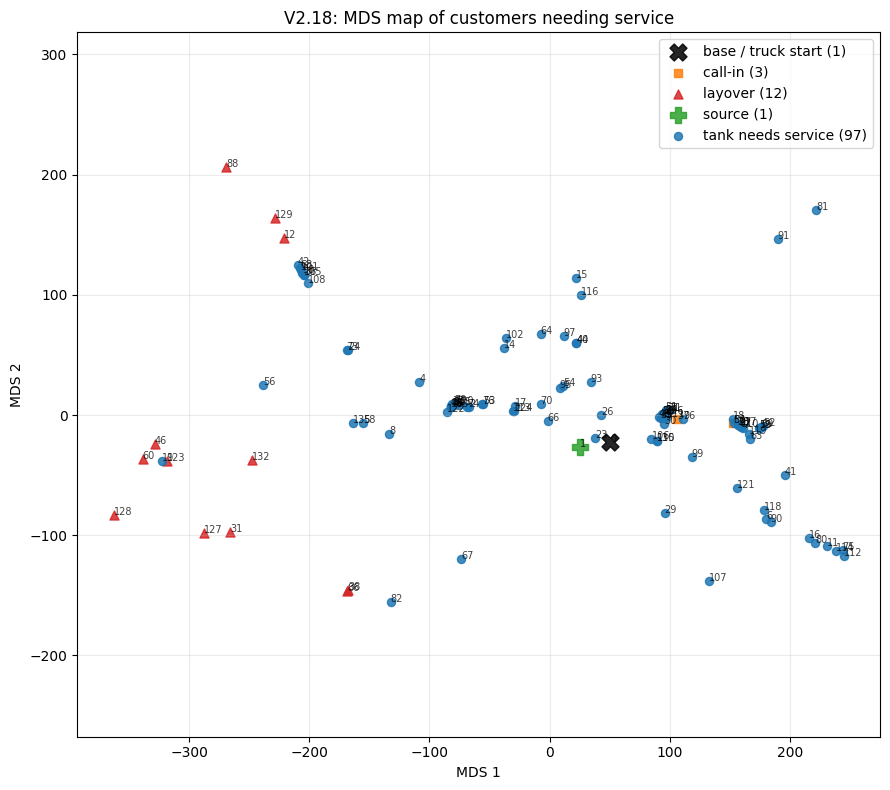

In [127]:
from sklearn.manifold import MDS

customer_by_id = {customer.index: customer for customer in selected_customers}
map_customer_ids = sorted(set(rate_by_customer) | set(call_in_rate_by_customer))

base_point_id = instance.base_index
source_point_ids = [source.index for source in instance.sources]
mds_point_ids = sorted(set(map_customer_ids) | set(source_point_ids) | {base_point_id})

if len(mds_point_ids) < 2:
    print("Need at least two customers for an MDS map.")
else:
    distance_matrix = np.asarray(instance.distance_matrix, dtype=float)
    mds_distances = distance_matrix[np.ix_(mds_point_ids, mds_point_ids)]
    mds_distances = (mds_distances + mds_distances.T) / 2
    np.fill_diagonal(mds_distances, 0.0)

    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress="auto")
    coords = mds.fit_transform(mds_distances)
    coords_by_point = {point_id: coords[idx] for idx, point_id in enumerate(mds_point_ids)}

    map_rows = []
    for customer_id in map_customer_ids:
        x, y = coords_by_point[customer_id]
        customer = customer_by_id[customer_id]
        if customer.call_in:
            group = "call-in"
        elif customer.layover_customer:
            group = "layover"
        else:
            group = "tank needs service"
        map_rows.append({"point_id": customer_id, "x": x, "y": y, "group": group})

    for source_id in source_point_ids:
        x, y = coords_by_point[source_id]
        map_rows.append({"point_id": source_id, "x": x, "y": y, "group": "source"})

    x, y = coords_by_point[base_point_id]
    map_rows.append({"point_id": base_point_id, "x": x, "y": y, "group": "base / truck start"})

    mds_map_df = pd.DataFrame(map_rows)
    display(mds_map_df.sort_values(["group", "point_id"], ignore_index=True))

    colors = {
        "tank needs service": "tab:blue",
        "call-in": "tab:orange",
        "layover": "tab:red",
        "source": "tab:green",
        "base / truck start": "black",
    }
    markers = {
        "tank needs service": "o",
        "call-in": "s",
        "layover": "^",
        "source": "P",
        "base / truck start": "X",
    }
    sizes = {
        "tank needs service": 34,
        "call-in": 38,
        "layover": 42,
        "source": 120,
        "base / truck start": 150,
    }

    fig, ax = plt.subplots(figsize=(9, 8))
    for group, group_df in mds_map_df.groupby("group"):
        ax.scatter(group_df["x"], group_df["y"], s=sizes[group], color=colors[group], marker=markers[group], label=f"{group} ({len(group_df)})", alpha=0.85)
        for _, row in group_df.iterrows():
            ax.text(row["x"], row["y"], str(int(row["point_id"])), fontsize=7, alpha=0.75)

    ax.set_title(f"{instance.name}: MDS map of customers needing service")
    ax.set_xlabel("MDS 1")
    ax.set_ylabel("MDS 2")
    ax.axis("equal")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

## Call-In Customers

Call-in customers are plotted separately because their tank levels are not tracked here. Each band is an order time window; the label is the requested volume.

Selected call-in customers: 3
Call-in order windows: 4


,customer_id,order,earliest_minute,latest_minute,earliest_hour,latest_hour,quantity,min_quantity_to_satisfy,quantity_flexibility
0,3,1,3720,6360,62.0,106.0,4400.0,3520.0,80
1,37,1,1440,1860,24.0,31.0,8000.0,6400.0,80
2,37,2,5760,6180,96.0,103.0,8000.0,6400.0,80
3,50,1,3180,3420,53.0,57.0,2931.0,2344.8,80


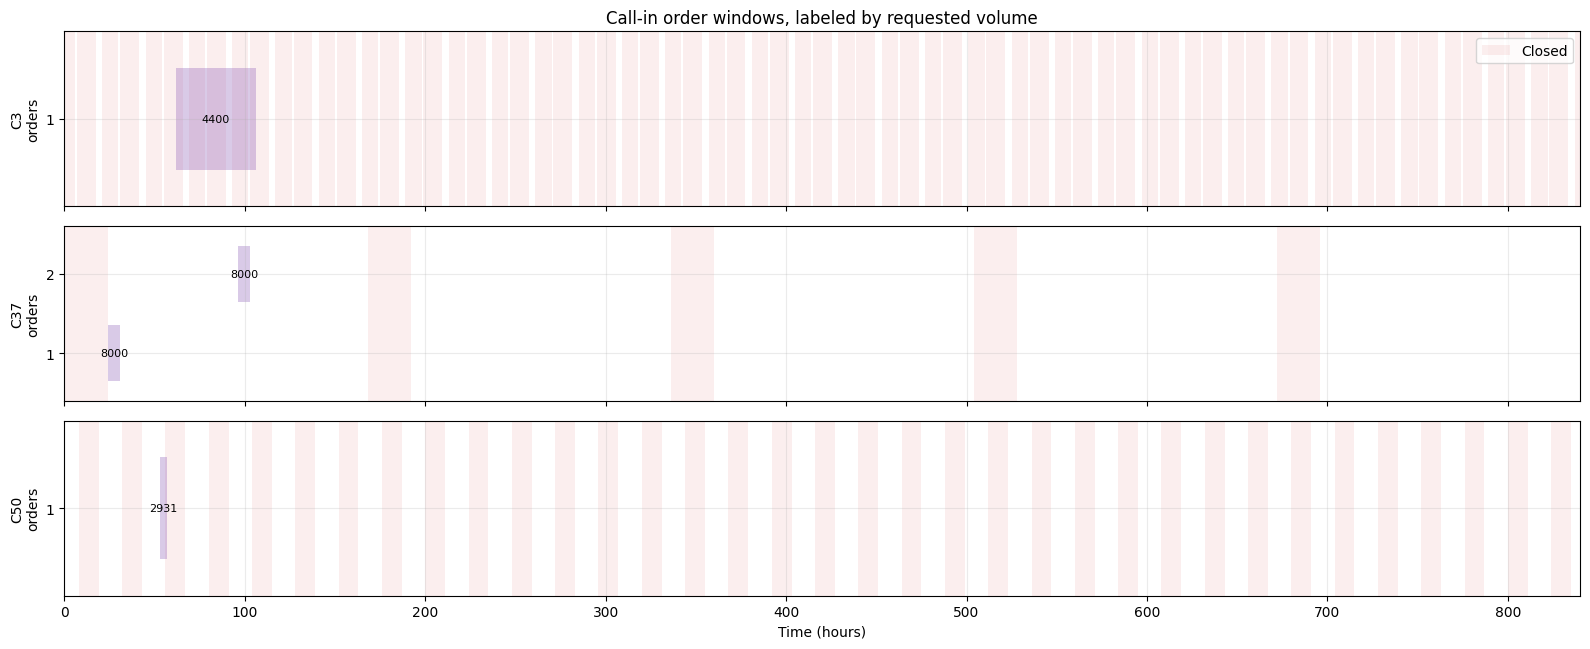

In [128]:
call_in_rows = []
for customer in call_in_customers:
    for order_idx, order in enumerate(customer.orders, start=1):
        call_in_rows.append(
            {
                "customer_id": customer.index,
                "order": order_idx,
                "earliest_minute": order.earliest_time,
                "latest_minute": order.latest_time,
                "earliest_hour": order.earliest_time / 60,
                "latest_hour": order.latest_time / 60,
                "quantity": order.quantity,
                "min_quantity_to_satisfy": order.min_quantity_to_satisfy,
                "quantity_flexibility": order.quantity_flexibility,
            }
        )

print(f"Selected call-in customers: {len(call_in_customers)}")
print(f"Call-in order windows: {len(call_in_rows)}")

if pd is not None and call_in_rows:
    call_in_order_df = pd.DataFrame(call_in_rows)
    display(call_in_order_df)

call_in_to_plot = [customer for customer in call_in_customers if customer.orders][:MAX_CALL_IN_ROWS]
if len([customer for customer in call_in_customers if customer.orders]) > MAX_CALL_IN_ROWS:
    print(f"Showing first {MAX_CALL_IN_ROWS} call-in customers with orders. Increase MAX_CALL_IN_ROWS to show more.")

if not call_in_to_plot:
    print("No selected call-in customers with orders to plot.")
else:
    fig_height = max(2.2 * len(call_in_to_plot), 3)
    fig, axes = plt.subplots(len(call_in_to_plot), 1, figsize=(16, fig_height), sharex=True, squeeze=False)

    for row_idx, customer in enumerate(call_in_to_plot):
        ax = axes[row_idx, 0]
        closed_intervals = closed_intervals_from_open_mask(open_mask_for_customer(customer, minutes))
        shade_closed(ax, closed_intervals, label_first=row_idx == 0)

        for order_idx, order in enumerate(customer.orders, start=1):
            start = max(order.earliest_time, 0) / 60
            end = min(order.latest_time, minutes) / 60
            width = max(end - start, 1 / 60)
            ax.broken_barh([(start, width)], (order_idx - 0.35, 0.7), facecolors="tab:purple", alpha=0.35)
            ax.text(start + width / 2, order_idx, f"{order.quantity:g}", ha="center", va="center", fontsize=8)

        ax.set_ylabel(f"C{customer.index}\norders")
        ax.set_yticks(range(1, len(customer.orders) + 1))
        ax.set_ylim(0.4, len(customer.orders) + 0.6)
        ax.set_xlim(0, hours)
        if row_idx == 0:
            ax.set_title("Call-in order windows, labeled by requested volume")
            ax.legend(loc="best")

    axes[-1, 0].set_xlabel("Time (hours)")
    fig.tight_layout()
    plt.show()

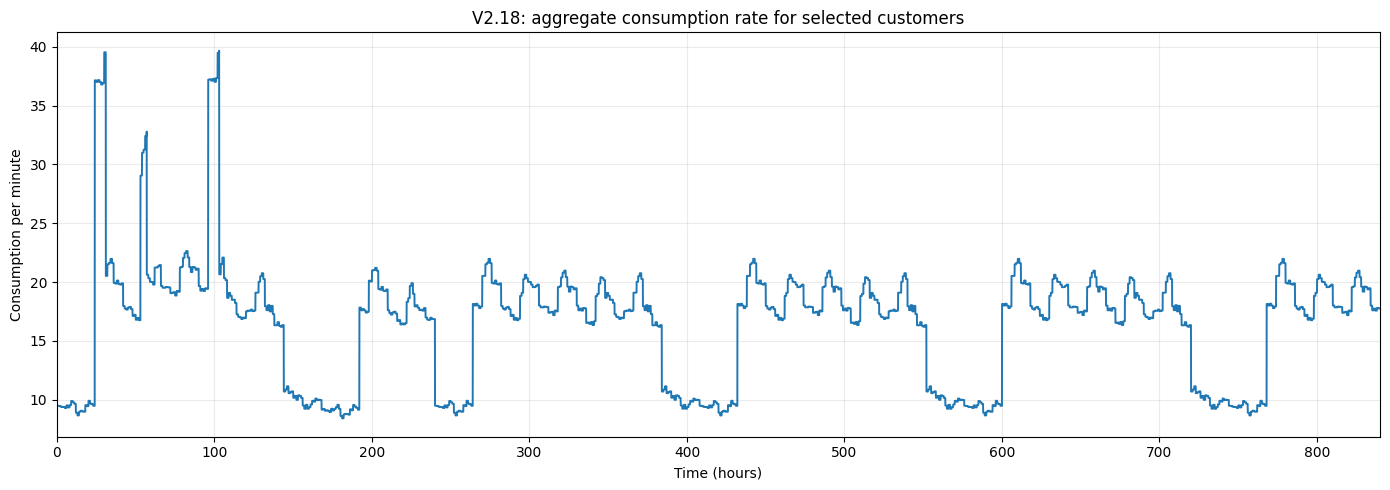

In [129]:
fig, ax = plt.subplots(figsize=(14, 5))

shade_closed(ax, aggregate_closed_intervals, label_first=True)
ax.plot(time_hour, total_rate, linewidth=1.4)
ax.set_title(f"{instance.name}: aggregate consumption rate for selected customers")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Consumption per minute")
ax.set_xlim(0, hours)
if aggregate_closed_intervals:
    ax.legend(loc="best")
fig.tight_layout()
plt.show()

Stacked plot will draw 30 row(s) from 109 selected customer(s). CUSTOMERS='all', MAX_CUSTOMER_ROWS=30.
Showing first 30 of 109 selected customers. Set CUSTOMERS to a smaller selection or increase MAX_CUSTOMER_ROWS to show more.


/var/folders/fq/8lhnn0pj6v59m6zg88wkq0z80000gn/T/ipykernel_13880/1857957778.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  rate_ax.legend(loc="best")


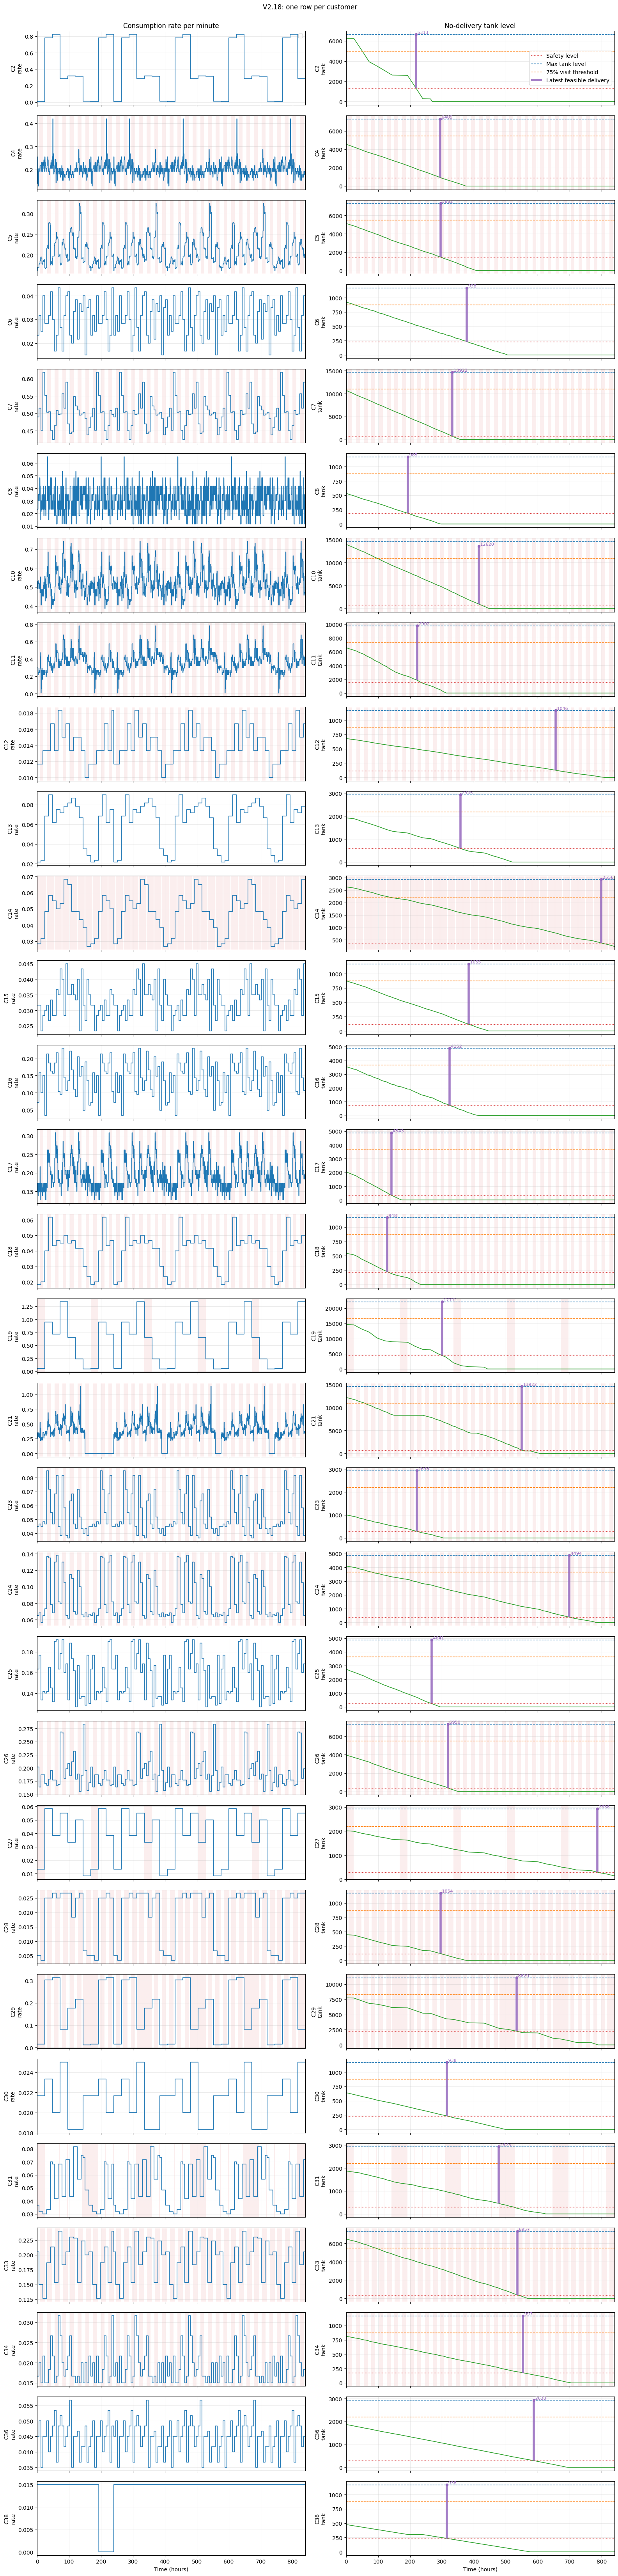

In [130]:
customer_items = list(rate_by_customer.items())
rows_to_plot = customer_items[:MAX_CUSTOMER_ROWS]
print(
    f"Stacked plot will draw {len(rows_to_plot)} row(s) "
    f"from {len(customer_items)} selected customer(s). "
    f"CUSTOMERS={CUSTOMERS!r}, MAX_CUSTOMER_ROWS={MAX_CUSTOMER_ROWS}."
)

if len(customer_items) > MAX_CUSTOMER_ROWS:
    print(
        f"Showing first {MAX_CUSTOMER_ROWS} of {len(customer_items)} selected customers. "
        "Set CUSTOMERS to a smaller selection or increase MAX_CUSTOMER_ROWS to show more."
    )

fig_height = max(2.2 * len(rows_to_plot), 3)
fig, axes = plt.subplots(
    len(rows_to_plot),
    2,
    figsize=(16, fig_height),
    sharex=True,
    squeeze=False,
)

for row_idx, (customer_id, rate) in enumerate(rows_to_plot):
    tank_level = tank_level_by_customer[customer_id]
    closed_intervals = closed_intervals_by_customer[customer_id]
    rate_ax, tank_ax = axes[row_idx]

    shade_closed(rate_ax, closed_intervals, label_first=row_idx == 0)
    rate_ax.plot(time_hour, rate, linewidth=1.2)
    rate_ax.set_ylabel(f"C{customer_id}\nrate")
    rate_ax.set_xlim(0, hours)
    if row_idx == 0:
        rate_ax.legend(loc="best")

    shade_closed(tank_ax, closed_intervals, label_first=row_idx == 0)
    tank_ax.plot(time_hour, tank_level, linewidth=1.2, color="tab:green")
    tank_ax.axhline(
        safety_level_by_customer[customer_id],
        linestyle=":",
        linewidth=1.0,
        color="tab:red",
        label="Safety level" if row_idx == 0 else None,
    )
    tank_ax.axhline(
        capacity_by_customer[customer_id],
        linestyle="--",
        linewidth=1.0,
        color="tab:blue",
        label="Max tank level" if row_idx == 0 else None,
    )
    tank_ax.axhline(
        0.75 * capacity_by_customer[customer_id],
        linestyle="--",
        linewidth=1.0,
        color="tab:orange",
        label="75% visit threshold" if row_idx == 0 else None,
    )

    delivery = latest_feasible_delivery(customer_id, tank_level)
    if delivery is not None:
        tank_ax.vlines(
            delivery["hour"],
            delivery["tank_before"],
            delivery["tank_after"],
            color="tab:purple",
            linewidth=4,
            alpha=0.85,
            label="Latest feasible delivery" if row_idx == 0 else None,
        )
        tank_ax.scatter(
            [delivery["hour"]],
            [delivery["tank_after"]],
            color="tab:purple",
            s=18,
            zorder=4,
        )
        tank_ax.text(
            delivery["hour"],
            delivery["tank_after"],
            f" {delivery['delivery_quantity']:.0f}",
            va="bottom",
            fontsize=8,
            color="tab:purple",
        )
    tank_ax.set_ylabel(f"C{customer_id}\ntank")
    tank_ax.set_xlim(0, hours)
    if row_idx == 0:
        tank_ax.legend(loc="best")

axes[0, 0].set_title("Consumption rate per minute")
axes[0, 1].set_title("No-delivery tank level")
axes[-1, 0].set_xlabel("Time (hours)")
axes[-1, 1].set_xlabel("Time (hours)")
fig.suptitle(f"{instance.name}: one row per customer", y=1.0)
fig.tight_layout()
plt.show()

## Tables for Further Analysis

## Total Candidate Delivery Volume Over Time

Candidate delivery events: 109
Total candidate delivery volume: 477,631.558


,customer_id,layover_customer,minute,hour,travel_time_from_source,latest_departure_minute,latest_departure_hour,delivery_quantity,tank_before,tank_after,safety_breach_minute
0,54,False,3840,64.000000,105,3735,62.250000,949.637010,222.762990,1172.4,3841
1,119,False,3865,64.416667,167,3698,61.633333,4427.960000,1107.040000,5535.0,3866
2,42,False,3941,65.683333,256,3685,61.416667,4396.450339,488.549661,4885.0,3942
3,71,False,5094,84.900000,92,5002,83.366667,2344.764020,586.235980,2931.0,5095
4,126,False,5169,86.150000,92,5077,84.616667,6961.055506,366.444494,7327.5,5170
...,...,...,...,...,...,...,...,...,...,...,...
104,27,False,47174,786.233333,149,47025,783.750000,2637.893526,293.106474,2931.0,47175
105,14,False,47940,799.000000,114,47826,797.100000,2556.298839,374.701161,2931.0,48370
106,67,False,48919,815.316667,199,48720,812.000000,1066.870035,105.529965,1172.4,48920
107,90,False,48943,815.716667,200,48743,812.383333,1055.146573,117.253427,1172.4,48944


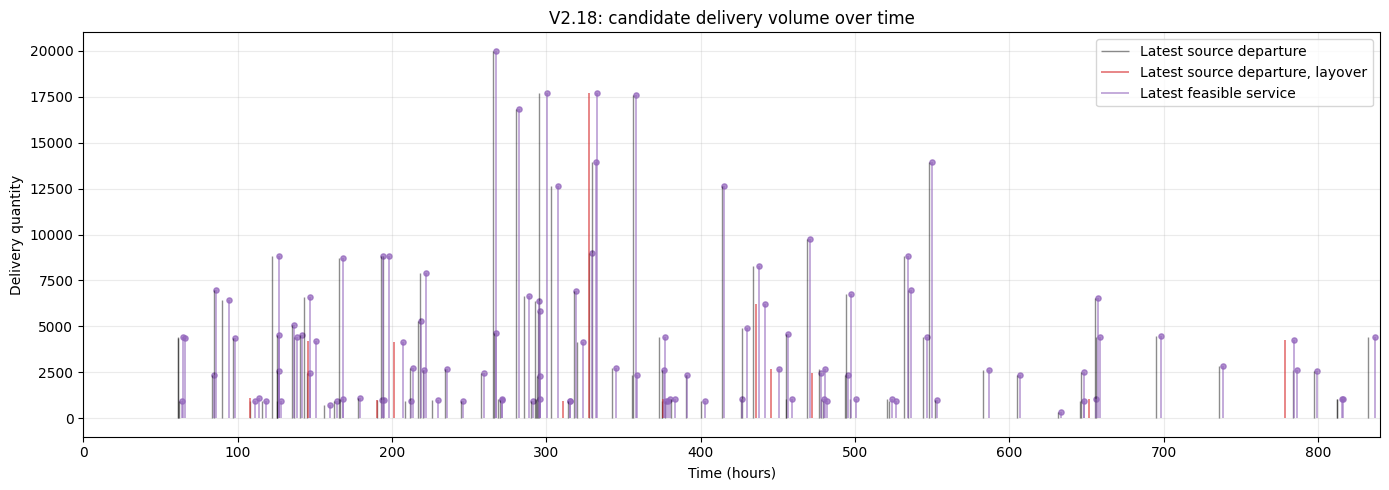

In [131]:
delivery_events = []
for customer_id, tank_level in tank_level_by_customer.items():
    delivery = latest_feasible_delivery(customer_id, tank_level)
    if delivery is not None:
        delivery_events.append(
            {
                "customer_id": customer_id,
                "layover_customer": layover_customer_by_id.get(customer_id, False),
                "minute": delivery["minute"],
                "hour": delivery["hour"],
                "travel_time_from_source": delivery["travel_time_from_source"],
                "latest_departure_minute": max(delivery["minute"] - delivery["travel_time_from_source"], 0),
                "latest_departure_hour": max(delivery["minute"] - delivery["travel_time_from_source"], 0) / 60,
                "delivery_quantity": delivery["delivery_quantity"],
                "tank_before": delivery["tank_before"],
                "tank_after": delivery["tank_after"],
                "safety_breach_minute": delivery["safety_breach_minute"],
            }
        )

delivery_volume_by_minute = np.zeros(minutes)
for event in delivery_events:
    delivery_volume_by_minute[event["minute"]] += event["delivery_quantity"]

print(f"Candidate delivery events: {len(delivery_events)}")
print(f"Total candidate delivery volume: {delivery_volume_by_minute.sum():,.3f}")

if pd is not None and delivery_events:
    delivery_event_df = pd.DataFrame(delivery_events).sort_values(["minute", "customer_id"], ignore_index=True)
    display(delivery_event_df)

fig, ax = plt.subplots(figsize=(14, 5))
if delivery_events:
    event_hours = np.array([event["hour"] for event in delivery_events])
    departure_hours = np.array([event["latest_departure_hour"] for event in delivery_events])
    event_volumes = np.array([event["delivery_quantity"] for event in delivery_events])
    layover_mask = np.array([event["layover_customer"] for event in delivery_events], dtype=bool)
    if np.any(~layover_mask):
        ax.vlines(departure_hours[~layover_mask], 0, event_volumes[~layover_mask], color="black", alpha=0.45, linewidth=1.0, label="Latest source departure")
    if np.any(layover_mask):
        ax.vlines(departure_hours[layover_mask], 0, event_volumes[layover_mask], color="tab:red", alpha=0.65, linewidth=1.2, label="Latest source departure, layover")
    ax.vlines(event_hours, 0, event_volumes, color="tab:purple", alpha=0.55, linewidth=1.4, label="Latest feasible service")
    ax.scatter(event_hours, event_volumes, color="tab:purple", s=14, alpha=0.75)
    ax.legend(loc="best")
else:
    ax.text(0.5, 0.5, "No feasible delivery markers", transform=ax.transAxes, ha="center", va="center")

ax.set_title(f"{instance.name}: candidate delivery volume over time")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Delivery quantity")
ax.set_xlim(0, hours)
fig.tight_layout()
plt.show()

In [133]:
import pandas as pd

minute_df = pd.DataFrame({
    "minute": time_minute,
    "hour": time_hour,
    "total_consumption_per_minute": total_rate,
    "cumulative_consumption": cumulative_consumption,
})
customer_total_df = pd.DataFrame(
    {
        "customer_id": list(rate_by_customer),
        "total_consumption": [float(np.nansum(rate)) for rate in rate_by_customer.values()],
    }
).sort_values("total_consumption", ascending=False, ignore_index=True)
display(minute_df.head())
display(customer_total_df.head(20))

,minute,hour,total_consumption_per_minute,cumulative_consumption
0,0,0.000000,9.493333,9.493333
1,1,0.016667,9.493333,18.986667
2,2,0.033333,9.493333,28.480000
3,3,0.050000,9.493333,37.973333
4,4,0.066667,9.493333,47.466667


,customer_id,total_consumption
0,48,41955.0
1,123,41280.0
2,19,29803.2
3,74,28819.2
4,10,26398.5
5,106,25269.6
6,7,25186.8
7,80,22329.6
8,114,22091.9
9,79,20539.6
